In [1]:
from datasets import load_dataset
import numpy as np

# There is only one split on the hub
dataset = load_dataset("OGB/ogbg-molhiv", cache_dir="./data")
seed = 42
dataset = dataset

/opt/miniconda3/envs/graphormer_lora/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# activate notebook autoload of files
%load_ext autoreload
%autoreload 2

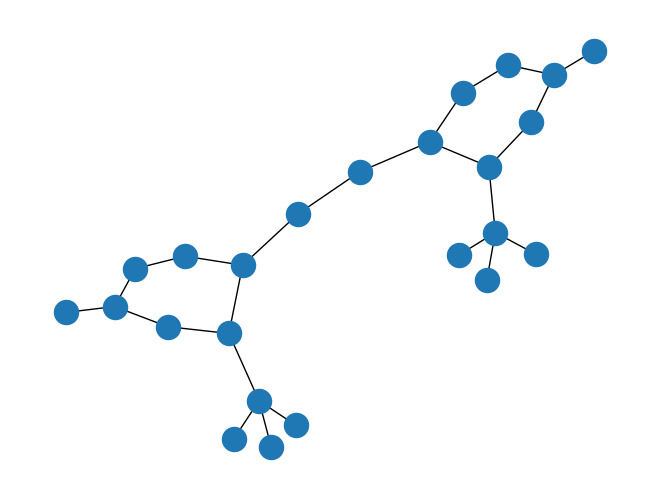

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# We want to plot the first train graph
graph = dataset["train"][0]
edges = graph["edge_index"]
num_edges = len(edges[0])
num_nodes = graph["num_nodes"]

# Conversion to networkx format
G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from([(edges[0][i], edges[1][i]) for i in range(num_edges)])

# Plot
nx.draw(G)


In [4]:
graph['num_nodes']

24

In [5]:
from transformers.models.graphormer.collating_graphormer import preprocess_item, GraphormerDataCollator

# dataset_processed = dataset.map(preprocess_item, batched=False)



In [6]:
from transformers import GraphormerForGraphClassification

model = GraphormerForGraphClassification.from_pretrained(
    "clefourrier/pcqm4mv2_graphormer_base",
    num_classes=2, # num_classes for the downstream task 
    ignore_mismatched_sizes=True,
)

/opt/miniconda3/envs/graphormer_lora/lib/python3.11/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of GraphormerForGraphClassification were not initialized from the model checkpoint at clefourrier/pcqm4mv2_graphormer_base and are newly initialized because the shapes did not match:
- classifier.classifier.weight: found shape torch.Size([1, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
model.get_memory_footprint(True) / (1024 ** 3)  # in GB

0.17761540785431862

In [8]:
model.to("mps")

GraphormerForGraphClassification(
  (encoder): GraphormerModel(
    (graph_encoder): GraphormerGraphEncoder(
      (dropout_module): Dropout(p=0.0, inplace=False)
      (graph_node_feature): GraphormerGraphNodeFeature(
        (atom_encoder): Embedding(4609, 768, padding_idx=0)
        (in_degree_encoder): Embedding(512, 768, padding_idx=0)
        (out_degree_encoder): Embedding(512, 768, padding_idx=0)
        (graph_token): Embedding(1, 768)
      )
      (graph_attn_bias): GraphormerGraphAttnBias(
        (edge_encoder): Embedding(1537, 32, padding_idx=0)
        (edge_dis_encoder): Embedding(131072, 1)
        (spatial_pos_encoder): Embedding(512, 32, padding_idx=0)
        (graph_token_virtual_distance): Embedding(1, 32)
      )
      (emb_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (layers): ModuleList(
        (0-11): 12 x GraphormerGraphEncoderLayer(
          (dropout_module): Dropout(p=0.0, inplace=False)
          (activation_dropout_module): Dr

In [9]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    "graph-classification/test/molhiv",
    logging_dir="graph-classification",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    auto_find_batch_size=False,
    gradient_accumulation_steps=4,
    dataloader_num_workers=8,
    num_train_epochs=4,
    evaluation_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc",
    push_to_hub=False,
    dataloader_drop_last=True,
    remove_unused_columns=False,  # CRITICAL: Don't remove columns - GraphormerDataCollator needs them!
    seed=seed,
    use_mps_device=True,  # Force MPS usage for both training and evaluation
    dataloader_prefetch_factor=2)

/opt/miniconda3/envs/graphormer_lora/lib/python3.11/site-packages/transformers/training_args.py:2046: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(


In [10]:
# check first the whole pipeline works on a smaller subset of the data
train = dataset["train"].with_format("numpy").select(range(100))
eval = dataset["validation"].with_format("numpy").select(range(1024))  # Same size as train

In [11]:
train.num_rows, eval.num_rows

(100, 1024)

In [12]:
# Fix for PyTorch 2.6+ checkpoint loading with numpy objects
import torch
import numpy as np

# Add numpy globals to safe globals list for checkpoint loading
# This includes numpy array types and all numpy dtype classes
torch.serialization.add_safe_globals([
    np.core.multiarray._reconstruct,
    np.ndarray,
    np.dtype,
    np.core.multiarray.scalar,
    # Add all numpy dtype classes
    np.dtypes.UInt32DType,
    np.dtypes.Int64DType,
    np.dtypes.Float64DType,
    np.dtypes.Float32DType,
    np.dtypes.Int32DType,
    np.dtypes.BoolDType,
    np.dtypes.ObjectDType,
])


/var/folders/qb/7wr1ckc131bbf7qtmmsjfdvw0000gr/T/ipykernel_26605/1523043076.py:8: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.
  np.core.multiarray._reconstruct,
/var/folders/qb/7wr1ckc131bbf7qtmmsjfdvw0000gr/T/ipykernel_26605/1523043076.py:11: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access func

In [13]:
from typing import Dict
import evaluate
from transformers import EvalPrediction
from trainer import Trainer

metric = evaluate.load("roc_auc")

def compute_metrics(eval_pred: EvalPrediction) -> Dict:
    logits, labels = eval_pred.predictions, eval_pred.label_ids.reshape(-1)
    predictions = np.argmax(logits, axis=-1)
    predictions = np.reshape(predictions, -1)
    result = metric.compute(prediction_scores=predictions, references=labels)
    return result

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train,
    eval_dataset=eval,
    data_collator=GraphormerDataCollator(on_the_fly_processing=True),
    compute_metrics=compute_metrics
)
train_results = trainer.evaluate()


/opt/miniconda3/envs/graphormer_lora/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
100%|██████████| 64/64 [00:50<00:00,  1.28it/s]


In [14]:
print(train_results)

{'eval_loss': 1.1956488266587257, 'eval_roc_auc': 0.5, 'eval_runtime': 53.8006, 'eval_samples_per_second': 19.033, 'eval_steps_per_second': 1.19}


In [ ]:
# DEBUG: Check what the trainer is actually using
print(f"Trainer args dataloader_num_workers: {trainer.args.dataloader_num_workers}")
print(f"Train dataset length: {len(trainer.train_dataset)}")
print(f"Train dataset type: {type(trainer.train_dataset)}")

# Try to manually create the train dataloader to see what happens
print("\nManually creating trainer's dataloader...")
try:
    train_dataloader = trainer.get_train_dataloader()
    print(f"Train DataLoader num_workers: {train_dataloader.num_workers}")
    print(f"Train DataLoader batch_size: {train_dataloader.batch_size}")
    print(f"Train DataLoader dataset length: {len(train_dataloader.dataset)}")
    
    # Try to fetch a batch
    print("Fetching first batch from trainer's dataloader...")
    batch = next(iter(train_dataloader))
    print("✓ Success!")
except Exception as e:
    print(f"✗ Failed: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*50)
print("If the above succeeded, the issue happens during train() itself")
print("="*50)

Trainer args dataloader_num_workers: 0
Train dataset length: 32901
Train dataset type: <class 'datasets.arrow_dataset.Dataset'>

Manually creating trainer's dataloader...
Creating train dataloader...
Train DataLoader num_workers: 0
Train DataLoader batch_size: 16
Train DataLoader dataset length: 32901
Fetching first batch from trainer's dataloader...
✓ Success!

If the above succeeded, the issue happens during train() itself


In [16]:
# Detailed timing analysis
import time
import torch

print("Dataset sizes:")
print(f"  Train: {len(train)} samples")
print(f"  Eval: {len(eval)} samples")
print(f"\nBatch configuration:")
print(f"  Train batch size: {training_args.per_device_train_batch_size}")
print(f"  Eval batch size: {training_args.per_device_eval_batch_size}")
print(f"  Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"  Effective train batch: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"\nExpected batches per epoch:")
print(f"  Train: {len(train) // training_args.per_device_train_batch_size}")
print(f"  Eval: {len(eval) // training_args.per_device_eval_batch_size}")

# Time a single forward pass
model.eval()
train_dataloader = trainer.get_train_dataloader()
eval_dataloader = trainer.get_eval_dataloader()

with torch.no_grad():
    # Train batch timing
    train_batch = next(iter(train_dataloader))
    train_batch = {k: v.to("mps") if isinstance(v, torch.Tensor) else v for k, v in train_batch.items()}
    start = time.time()
    _ = model(**train_batch)
    torch.mps.synchronize()
    train_time = time.time() - start
    
    # Eval batch timing
    eval_batch = next(iter(eval_dataloader))
    eval_batch = {k: v.to("mps") if isinstance(v, torch.Tensor) else v for k, v in eval_batch.items()}
    start = time.time()
    _ = model(**eval_batch)
    torch.mps.synchronize()
    eval_time = time.time() - start

print(f"\nSingle batch forward pass timing:")
print(f"  Train batch ({training_args.per_device_train_batch_size} samples): {train_time:.4f}s")
print(f"  Eval batch ({training_args.per_device_eval_batch_size} samples): {eval_time:.4f}s")
print(f"  Time per sample (train): {train_time/training_args.per_device_train_batch_size:.4f}s")
print(f"  Time per sample (eval): {eval_time/training_args.per_device_eval_batch_size:.4f}s")

Dataset sizes:
  Train: 512 samples
  Eval: 1024 samples

Batch configuration:
  Train batch size: 16
  Eval batch size: 16
  Gradient accumulation: 4
  Effective train batch: 64

Expected batches per epoch:
  Train: 32
  Eval: 64

Single batch forward pass timing:
  Train batch (16 samples): 2.4524s
  Eval batch (16 samples): 2.9022s
  Time per sample (train): 0.1533s
  Time per sample (eval): 0.1814s


## Why Evaluation is Slower

The Trainer's evaluation process is inherently slower because:

1. **Prediction gathering**: Must synchronize and gather all predictions to CPU for metrics
2. **No gradient accumulation**: Training batches are pipelined (4 batches before optimizer step), eval processes each batch independently
3. **Memory overhead**: Stores all logits and labels for metric computation
4. **MPS synchronization**: Must call `torch.mps.synchronize()` after each prediction batch

### Solutions:
- Use larger `per_device_eval_batch_size` (less synchronization overhead)
- Reduce eval dataset size for faster validation
- Evaluate less frequently (e.g., `evaluation_strategy="steps"` with larger `eval_steps`)
- Disable `dataloader_drop_last` for eval to process all samples

In [ ]:
# OPTIMIZATION: Faster training args that reduce eval overhead
from transformers import TrainingArguments

training_args_optimized = TrainingArguments(
    "graph-classification/test/molhiv",
    logging_dir="graph-classification",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,  # Much larger eval batch - no gradients needed!
    auto_find_batch_size=False,
    gradient_accumulation_steps=4,
    dataloader_num_workers=2,
    num_train_epochs=4,
    evaluation_strategy="steps",  # Evaluate by steps instead of every epoch
    eval_steps=100,  # Evaluate every 100 steps
    logging_strategy="steps",
    logging_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
    dataloader_pin_memory=False,
    dataloader_drop_last=True,
    remove_unused_columns=False,
    seed=seed,
    use_mps_device=True,
    dataloader_prefetch_factor=2,
    eval_accumulation_steps=4,  # KEY: Accumulate eval predictions to reduce synchronization!
)

# This setting ^^ reduces memory transfer overhead during evaluation